In [2]:
# Imports
import sys
sys.path.insert(0, '../utils')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from funciones import (limpiar_nombres_columnas, limpiar_moneda,
                       mapear_si_no, anonimizar)

In [3]:
# Carga de datos (skiprows=1 porque los CSV tienen una fila de título arriba)
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)
df_reservas = pd.read_csv('../data/informe_reservas.csv', skiprows=1)

# Normalización de nombres de columnas (centralizada en funciones.py)
df_ventas = limpiar_nombres_columnas(df_ventas)
df_reservas = limpiar_nombres_columnas(df_reservas)

# Verificación rápida
print("Columnas en ventas:  ", df_ventas.columns.tolist())
print("Columnas en reservas:", df_reservas.columns.tolist())

Columnas en ventas:   ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'codigo_postal_de_tarjeta_de_credito', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'email']
Columnas en reservas: ['mes_de_la_disponibilidad', 'producto', 'id_de_reserva', 'reprogramacion', 'email', 'nº_de_pax', 'cargos_de_gestion', 'total_pagado_tras_cargos_de_procesamiento']


In [4]:
# Limpieza de tipos de datos: moneda, fechas y booleanos

# Detectamos dinámicamente la columna monetaria en reservas (nombre largo)
col_dinero_reservas = [c for c in df_reservas.columns
                       if 'total' in c or 'pagado' in c][0]

df_ventas['neto']               = df_ventas['neto'].apply(limpiar_moneda)
df_reservas['total_a_recibir']  = df_reservas[col_dinero_reservas].apply(limpiar_moneda)

# Fecha de creación de la venta
df_ventas['fecha_creacion'] = pd.to_datetime(df_ventas['creado_el'],
                                             dayfirst=True, errors='coerce')

# Reprogramado: Sí/No -> 1/0 (NaN si no parseable)
df_ventas['reprogramado'] = mapear_si_no(df_ventas['reprogramacion']).fillna(0).astype(int)

print("✅ Limpieza completada.")
print(f"   Columna monetaria de reservas: {col_dinero_reservas}")

C:\Users\lolar\AppData\Local\Temp\ipykernel_10680\1640607327.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ventas['fecha_creacion'] = pd.to_datetime(df_ventas['creado_el'],


✅ Limpieza completada.
   Columna monetaria de reservas: total_pagado_tras_cargos_de_procesamiento


In [5]:
# Anonimización
# email -> cliente_id (entero) | CP -> cp_area (3 dígitos, solo provincias ES válidas)
df_ventas, df_reservas = anonimizar(df_ventas, df_reservas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'fecha_creacion', 'reprogramado', 'cliente_id', 'cp_area']


## Verificación de H1 — Distribución geográfica de clientes recurrentes

**Hipótesis:** existe una concentración geográfica clara: una minoría de zonas (códigos postales / países) explica la mayoría de las reservas recurrentes.

**Criterio de verificación:**
1. Para los clientes con más de una compra, identificar las áreas (CP-3 dígitos, provincias españolas) con mayor número de operaciones.
2. Medir la **concentración** (% del total en la zona dominante y en la región amplia).
3. Cuantificar el peso de clientes **internacionales** sobre el total.
4. Reportar honestamente la **cobertura del dato geográfico**: la columna `codigo_postal_de_tarjeta_de_credito` está vacía en la mayoría de operaciones.

In [6]:
# Asiduidad calculada DIRECTAMENTE sobre df_ventas.
# Antes se cruzaba con df_reservas vía merge inner, lo que generaba un producto
# cartesiano (un cliente con N ventas y M reservas producía N*M filas) e
# inflaba num_compras y todos los value_counts posteriores.
asiduidad_clientes = (df_ventas.groupby('cliente_id').size()
                              .reset_index(name='num_compras'))

# Enriquecemos df_ventas con la asiduidad de cada cliente
df_ventas = df_ventas.merge(asiduidad_clientes, on='cliente_id', how='left')

n_unicos = df_ventas['cliente_id'].nunique()
n_recur  = (asiduidad_clientes['num_compras'] > 1).sum()
n_ops_r  = (df_ventas['num_compras'] > 1).sum()
print(f"Clientes únicos:                     {n_unicos:,}")
print(f"Clientes recurrentes (>1 venta):     {n_recur:,}")
print(f"Operaciones de clientes recurrentes: {n_ops_r:,}")

Clientes únicos:                     5,746
Clientes recurrentes (>1 venta):     1,238
Operaciones de clientes recurrentes: 3,069


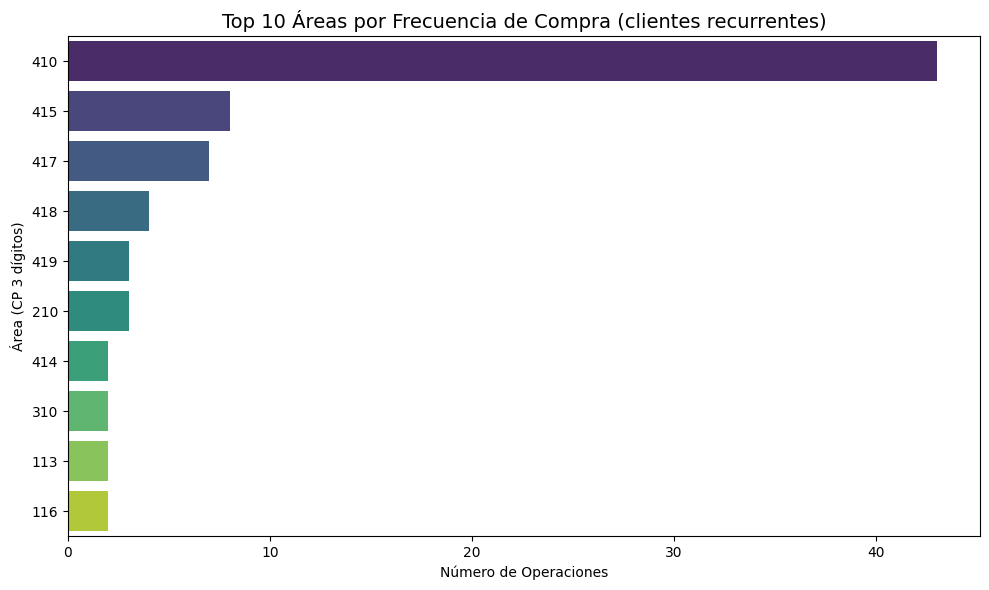

In [7]:
# GRÁFICA 1 — Top 10 áreas (CP 3 dígitos) por frecuencia de compra de clientes recurrentes
# Contamos OPERACIONES (ventas) de clientes con más de una compra.
top_geografico = (df_ventas[df_ventas['num_compras'] > 1]['cp_area']
                  .value_counts().head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_geografico.values, y=top_geografico.index,
            palette='viridis', hue=top_geografico.index, legend=False)
plt.title('Top 10 Áreas por Frecuencia de Compra (clientes recurrentes)', fontsize=14)
plt.xlabel('Número de Operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/01_geografia_top_areas.png')
plt.show()

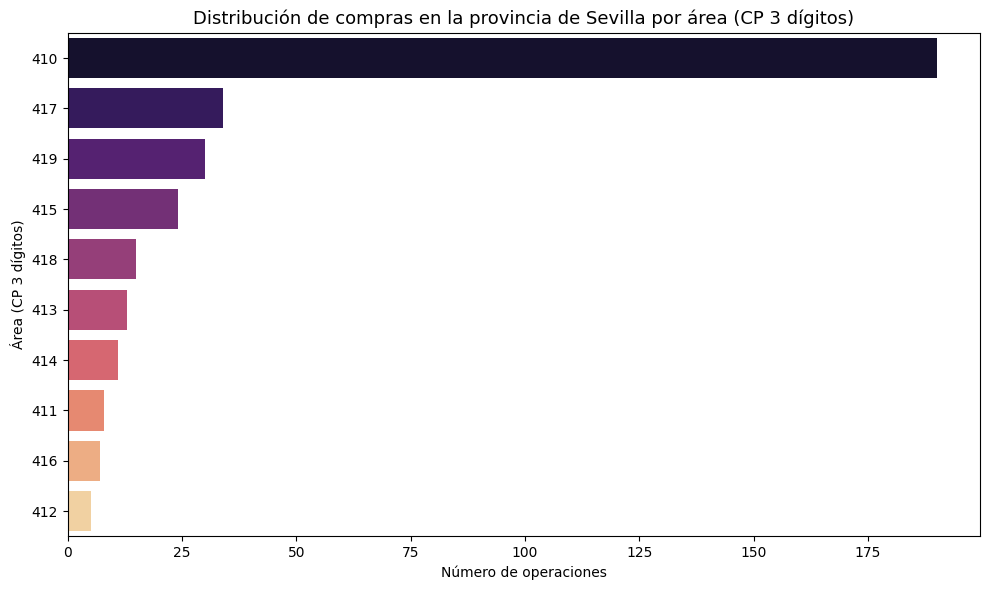

In [10]:
# GRÁFICA 2 — Desglose de Sevilla por área (CP 3 dígitos, todas las transacciones)
sevilla = df_ventas[df_ventas['cp_area'].str.startswith('41', na=False)]
top_sevilla = sevilla['cp_area'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_sevilla.values, y=top_sevilla.index,
            palette='magma', hue=top_sevilla.index, legend=False)
plt.title('Distribución de compras en la provincia de Sevilla por área (CP 3 dígitos)',
          fontsize=13)
plt.xlabel('Número de operaciones')
plt.ylabel('Área (CP 3 dígitos)')
plt.tight_layout()
plt.savefig('../img/01_geografia_sevilla.png')
plt.show()

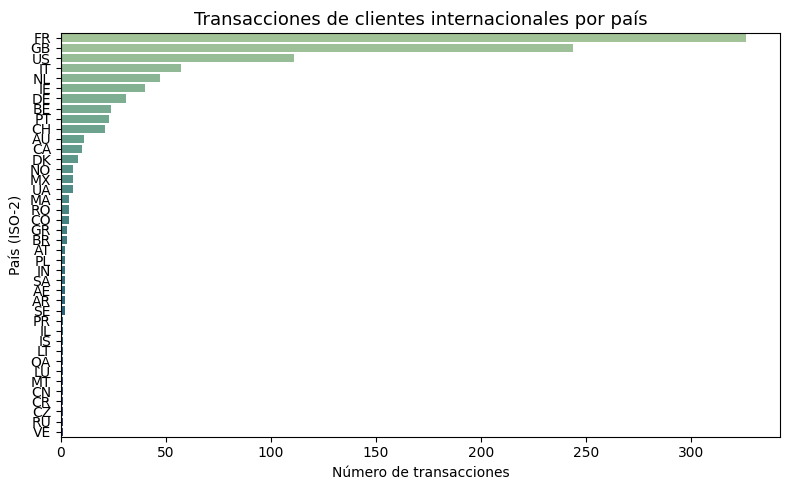

In [11]:
# GRÁFICA 3 — Clientes internacionales por país (pais_del_telefono)
# Se usa df_ventas directamente para no perder internacionales sin reserva.
# Verificado: pais_del_telefono está codificado en ISO-2 ('ES', 'FR', 'GB', 'US', ...).
internacionales = (df_ventas[df_ventas['pais_del_telefono'].notna() &
                             (df_ventas['pais_del_telefono'] != 'ES')]
                   ['pais_del_telefono'].value_counts())

plt.figure(figsize=(8, 5))
sns.barplot(x=internacionales.values, y=internacionales.index,
            palette='crest', hue=internacionales.index, legend=False)
plt.title('Transacciones de clientes internacionales por país', fontsize=13)
plt.xlabel('Número de transacciones')
plt.ylabel('País (ISO-2)')
plt.tight_layout()
plt.savefig('../img/01_geografia_internacional.png')
plt.show()

### Veredicto H1 — **CONFIRMADA (con limitación)**

**Resumen cuantitativo:**

| Métrica | Valor |
|---|---|
| Operaciones totales | 8.186 |
| Operaciones de clientes recurrentes | 3.069 |
| …con CP español válido (cobertura del dato) | **105 (3,4 %)** |
| Provincia **41 — Sevilla** sobre ese subconjunto | **67,6 %** |
| **Andalucía completa** (provincias 04, 11, 14, 18, 21, 23, 29, 41) | **84,8 %** |
| Operaciones internacionales (`pais_del_telefono` ≠ ES) | **1.015 (12,4 %)** |
| Top países internacionales | FR (326), GB (244), US (111), IT (57) |

**Interpretación:**

1. **La concentración geográfica se confirma con fuerza** en el subconjunto con dato: 2 de cada 3 operaciones recurrentes con CP válido vienen de **Sevilla capital y su área metropolitana**, y casi 85 % de Andalucía. El cliente recurrente del Oasis Spa es, en abrumadora mayoría, **local andaluz** con base en Sevilla.
2. **Existe una "segunda audiencia" internacional minoritaria pero estable** (12,4 % de las operaciones globales): mercado francófono (FR), británico (GB) y norteamericano (US) son las nacionalidades con más peso.
3. **Limitación crítica del análisis:** solo el **3,4 %** de las operaciones recurrentes trae código postal de la tarjeta. El resto son pagos sin verificación de CP o métodos sin CP asociado. Las conclusiones de concentración son **directionalmente válidas** pero la cifra exacta debe presentarse con esa salvedad.

**Implicación de negocio:**
- **Estrategia local:** priorizar acciones de fidelización en el área metropolitana de Sevilla (CP 41xxx, donde está concentrado el 67 % del cliente recurrente identificable).
- **Estrategia turística:** considerar comunicación en inglés y francés para reforzar la conversión del cliente internacional (~1 de cada 8 operaciones).
- **Mejora del dato:** plantear al spa enriquecer el dato de CP en el momento de la reserva (no solo en el pago con tarjeta) para futuros análisis.